In [1]:
#imports

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [4]:
# load dataset

data = np.load("shared_ring_dataset.npz")

# choose observation level here
OBS_LEVELS = {
    "100%": "X_rates_obs_100",
    "50%":  "X_rates_obs_50",
    "25%":  "X_rates_obs_25",
    "10%":  "X_rates_obs_10",
}

Y = data["Y_rates"]
Y_theta = data["Y_theta"]

train_idx = data["train_idx"]
test_idx  = data["test_idx"]

print("Available observation levels:", OBS_LEVELS)
print("Y shape:", Y.shape)
print("Y_theta shape:", Y_theta.shape)

Available observation levels: {'100%': 'X_rates_obs_100', '50%': 'X_rates_obs_50', '25%': 'X_rates_obs_25', '10%': 'X_rates_obs_10'}
Y shape: (40, 1000, 100)
Y_theta shape: (40, 1000)


In [6]:
# define Vanilla RNN (same as in 02)

class VanillaRateRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, alpha=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.alpha = alpha

        self.W_xh = nn.Linear(input_dim, hidden_dim)
        self.W_hh = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_hy = nn.Linear(hidden_dim, output_dim)

        self.nonlinearity = torch.tanh

    def forward(self, x, h0=None):
        B, T, _ = x.shape

        if h0 is None:
            h = torch.zeros(B, self.hidden_dim, device=x.device)
        else:
            h = h0

        ys = []
        hs = []

        for t in range(T):
            pre = self.W_xh(x[:, t]) + self.W_hh(h)
            h = (1 - self.alpha) * h + self.alpha * self.nonlinearity(pre)
            y = self.W_hy(h)

            ys.append(y.unsqueeze(1))
            hs.append(h.unsqueeze(1))

        y_hat = torch.cat(ys, dim=1)
        h_all = torch.cat(hs, dim=1)

        return y_hat, h_all

In [7]:
# decode angle

def decode_angle(rates):
    """
    rates: [T, N]
    returns: [T]
    """
    N = rates.shape[1]
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)

    x = (rates * np.cos(angles)).sum(axis=1)
    y = (rates * np.sin(angles)).sum(axis=1)

    return np.arctan2(y, x)

In [10]:
# circular angle error 

def circular_angle_error(theta_pred, theta_true):
    """
    theta_pred, theta_true: arrays of same shape
    returns mean absolute circular error
    """
    diff = np.angle(np.exp(1j * (theta_pred - theta_true)))
    return np.mean(np.abs(diff))

In [11]:
# training/evaluation function

def train_and_evaluate_vanilla(X, Y, Y_theta, train_idx, test_idx,
                               hidden_dim=100, alpha=0.1,
                               lr=1e-3, n_epochs=300):
    # convert to torch
    X_train = torch.tensor(X[train_idx], dtype=torch.float32)
    Y_train = torch.tensor(Y[train_idx], dtype=torch.float32)

    X_test  = torch.tensor(X[test_idx], dtype=torch.float32)
    Y_test  = torch.tensor(Y[test_idx], dtype=torch.float32)

    Y_theta_train = Y_theta[train_idx]
    Y_theta_test  = Y_theta[test_idx]

    # model
    input_dim = X_train.shape[-1]
    output_dim = Y_train.shape[-1]

    model = VanillaRateRNN(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        alpha=alpha
    )

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []

    # training
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()

        y_hat, _ = model(X_train)
        loss = criterion(y_hat, Y_train)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    # evaluation
    model.eval()
    with torch.no_grad():
        y_pred_train, h_train = model(X_train)
        y_pred_test, h_test = model(X_test)

    train_mse = criterion(y_pred_train, Y_train).item()
    test_mse = criterion(y_pred_test, Y_test).item()

    # decode angles from predicted rates
    y_pred_test_np = y_pred_test.cpu().numpy()
    theta_pred_test = np.array([decode_angle(y_pred_test_np[i]) for i in range(y_pred_test_np.shape[0])])

    angle_err_test = circular_angle_error(theta_pred_test, Y_theta_test)

    return {
        "model": model,
        "losses": losses,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "angle_err_test": angle_err_test,
        "y_pred_test": y_pred_test,
        "h_test": h_test,
        "theta_pred_test": theta_pred_test,
        "Y_theta_test": Y_theta_test,
    }

In [12]:
# run all observation levels

results = {}

for label, x_key in OBS_LEVELS.items():
    print(f"\nRunning observation level: {label}")
    X = data[x_key]

    out = train_and_evaluate_vanilla(
        X=X,
        Y=Y,
        Y_theta=Y_theta,
        train_idx=train_idx,
        test_idx=test_idx,
        hidden_dim=100,
        alpha=0.1,
        lr=1e-3,
        n_epochs=300,
    )

    results[label] = out

    print(f"  Train MSE: {out['train_mse']:.6f}")
    print(f"  Test MSE : {out['test_mse']:.6f}")
    print(f"  Angle err: {out['angle_err_test']:.6f}")


Running observation level: 100%
  Train MSE: 0.000037
  Test MSE : 0.000104
  Angle err: 0.101236

Running observation level: 50%
  Train MSE: 0.000052
  Test MSE : 0.000124
  Angle err: 0.212660

Running observation level: 25%
  Train MSE: 0.000071
  Test MSE : 0.000145
  Angle err: 0.234531

Running observation level: 10%
  Train MSE: 0.000121
  Test MSE : 0.000172
  Angle err: 0.422994


In [15]:
# table result summary 
import pandas as pd
summary_df = pd.DataFrame(summary)
summary_df

,obs_level,train_mse,test_mse,angle_err_test
0,100%,0.000037,0.000104,0.101236
1,50%,0.000052,0.000124,0.212660
2,25%,0.000071,0.000145,0.234531
3,10%,0.000121,0.000172,0.422994


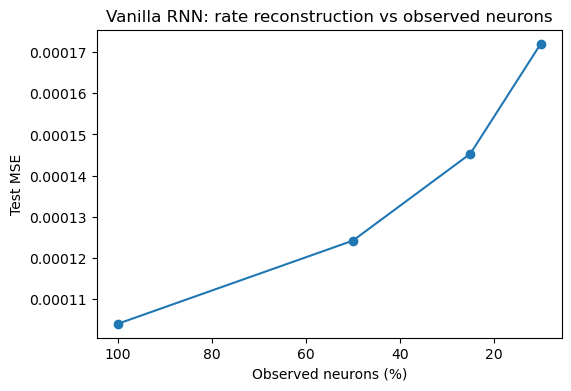

In [16]:
# plot test MSE vs observed neurons

obs_numeric = [100, 50, 25, 10]
test_mse_vals = [results["100%"]["test_mse"],
                 results["50%"]["test_mse"],
                 results["25%"]["test_mse"],
                 results["10%"]["test_mse"]]

plt.figure(figsize=(6,4))
plt.plot(obs_numeric, test_mse_vals, marker="o")
plt.gca().invert_xaxis()
plt.xlabel("Observed neurons (%)")
plt.ylabel("Test MSE")
plt.title("Vanilla RNN: rate reconstruction vs observed neurons")
plt.show()

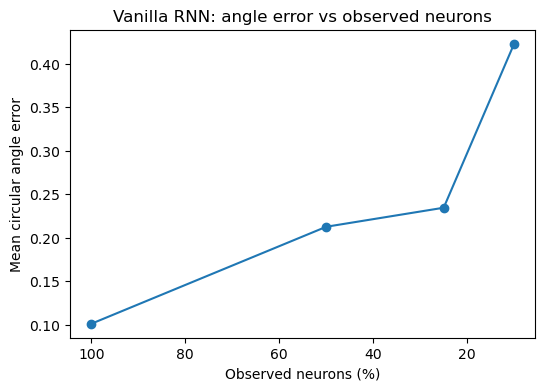

In [17]:
# plot angle error vs observed neurons

angle_err_vals = [results["100%"]["angle_err_test"],
                  results["50%"]["angle_err_test"],
                  results["25%"]["angle_err_test"],
                  results["10%"]["angle_err_test"]]

plt.figure(figsize=(6,4))
plt.plot(obs_numeric, angle_err_vals, marker="o")
plt.gca().invert_xaxis()
plt.xlabel("Observed neurons (%)")
plt.ylabel("Mean circular angle error")
plt.title("Vanilla RNN: angle error vs observed neurons")
plt.show()

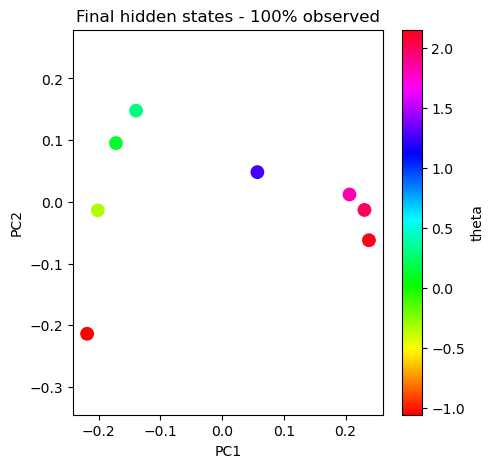

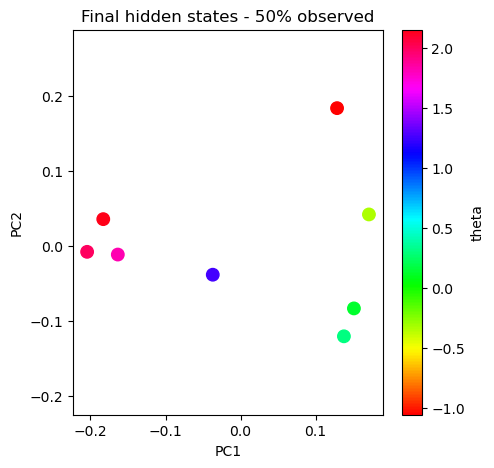

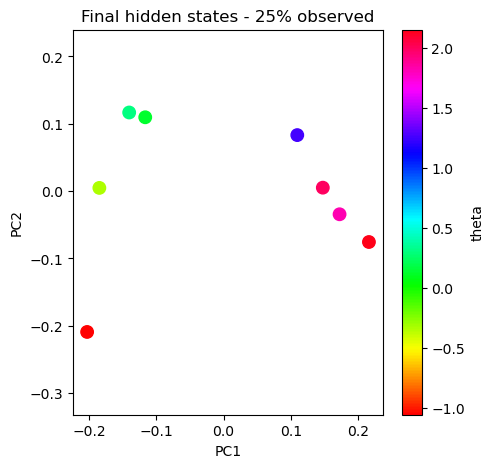

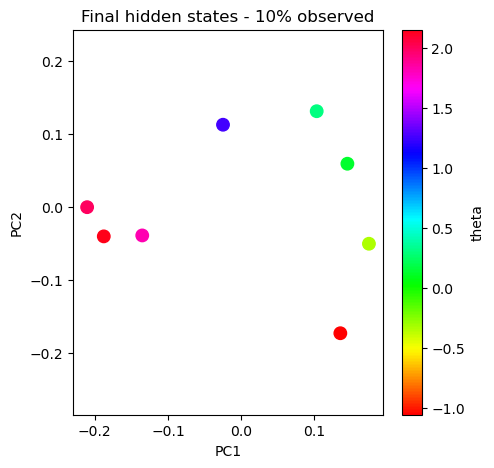

In [27]:
# compare final hidden states for each observation level

from sklearn.decomposition import PCA

for label in OBS_LEVELS.keys():
    h_test = results[label]["h_test"]

    h_last = h_test[:, -1, :].cpu().numpy()
    theta_last = results[label]["Y_theta_test"][:, -1]

    pca = PCA(n_components=2)
    h_last_pca = pca.fit_transform(h_last)

    plt.figure(figsize=(5,5))
    sc = plt.scatter(h_last_pca[:,0], h_last_pca[:,1], c=theta_last, cmap="hsv", s=80)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"Final hidden states - {label} observed")
    plt.colorbar(sc, label="theta")
    plt.axis("equal")
    plt.show()

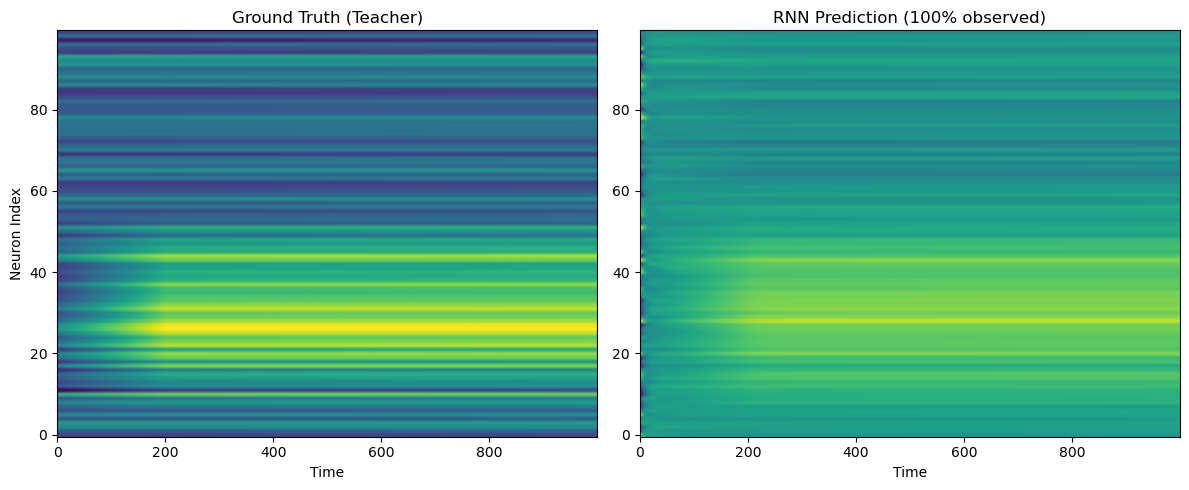

In [22]:
# reconstruction heatmap for one trial
selected_level = "100%"   # choose one observation level to inspect

X_key = OBS_LEVELS[selected_level]
X = data[X_key]

X_test = torch.tensor(X[test_idx], dtype=torch.float32)
Y_test = torch.tensor(Y[test_idx], dtype=torch.float32)

model = results[selected_level]["model"]
model.eval()

with torch.no_grad():
    y_pred_test, _ = model(X_test)

trial_idx = 0
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(Y_test[trial_idx].cpu().T, aspect='auto', origin='lower', cmap='viridis')
ax[0].set_title("Ground Truth (Teacher)")
ax[0].set_ylabel("Neuron Index")
ax[0].set_xlabel("Time")

ax[1].imshow(y_pred_test[trial_idx].cpu().T, aspect='auto', origin='lower', cmap='viridis')
ax[1].set_title(f"RNN Prediction ({selected_level} observed)")
ax[1].set_xlabel("Time")

plt.tight_layout()
plt.show()

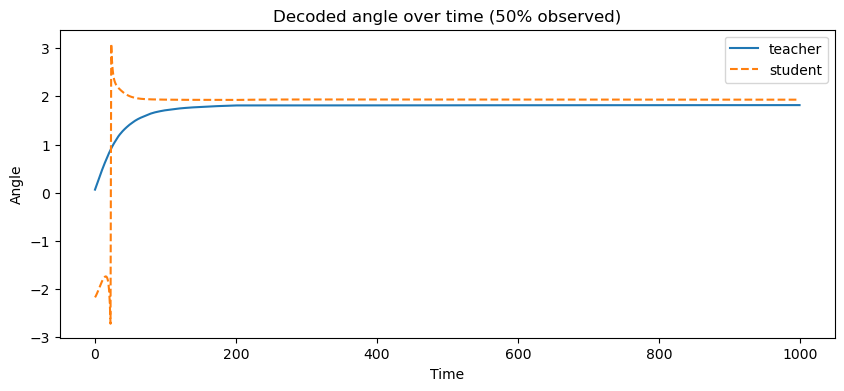

In [25]:
# Predicted-vs-true angle plot for one trial, for each observation level

selected_level = "50%"
trial_idx = 0

theta_true = results[selected_level]["Y_theta_test"][trial_idx]
theta_pred = results[selected_level]["theta_pred_test"][trial_idx]

plt.figure(figsize=(10,4))
plt.plot(theta_true, label="teacher")
plt.plot(theta_pred, "--", label="student")
plt.title(f"Decoded angle over time ({selected_level} observed)")
plt.xlabel("Time")
plt.ylabel("Angle")
plt.legend()
plt.show()

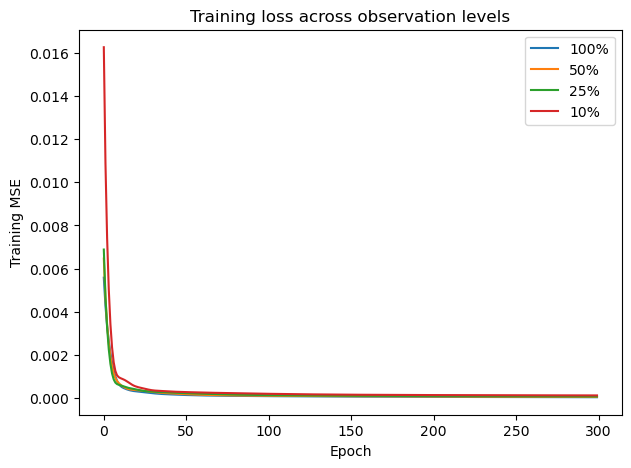

In [26]:
# Training-loss curves for all observation levels

plt.figure(figsize=(7,5))
for label in OBS_LEVELS.keys():
    plt.plot(results[label]["losses"], label=label)
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Training loss across observation levels")
plt.legend()
plt.show()